In [1]:
from Hamiltonian1D import SpinChain1D
from classes import NeuralQuantumState, FFN, CNN, RBM, Sampler, TFIM, Optimizer, Observables
import numpy as np
from scipy.sparse import lil_matrix, kron, identity, csr_matrix
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from functions import von_neumann_entropy, renyi2_entropy_ED
import jax
import jax.numpy as jnp
from jax import random
from functools import partial
import optax

In [2]:
L = 16
J, g, g_critical = 1.0, 0.5, 1.0
H, H_critical= SpinChain1D(L), SpinChain1D(L)

In [3]:
H.add_zz(J)
H_critical.add_zz(J)

In [4]:
H.add_x_field(g)
H_critical.add_x_field(g_critical)

In [5]:
H = H.build()
H_critical = H_critical.build()


In [6]:
num_eigs = 1  # compute lowest eigenvalue
eigs, vecs = eigsh(H, k=num_eigs, which='SA')
print(f"Ground state energy: {eigs[0]:.6f}")
print(f"Eigenket: {vecs[0]}")

Ground state energy: -16.146051
Eigenket: [-1.9644367e-07]


In [7]:
gs_energy_critical, gs_critical = eigsh(H_critical, k=1, which='SA')
gs_energy, gs = eigsh(H, k=1, which='SA')

gs_energy = gs_energy[0]
gs_energy_critical = gs_energy_critical[0]

Physical meaning of eigenvalues λᵢ

They are the Schmidt coefficients squared of 
∣ψ⟩ in the bipartition A⊗B


In Matrix Product States language: the number of significant λᵢ tells us the bond dimension needed to represent the state efficiently.

More non-zero λᵢ → more entanglement → higher bond dimension

In [8]:
subsys_size = list(range(1,L//2 + 1))
S1_critical = [von_neumann_entropy(gs_critical, L, LA) for LA in subsys_size] 
S1 = [von_neumann_entropy(gs, L, LA) for LA in subsys_size]

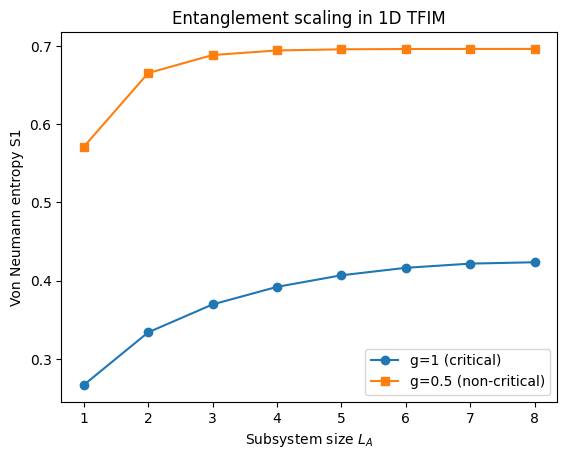

In [9]:
plt.plot(subsys_size, S1_critical, 'o-', label='g=1 (critical)')
plt.plot(subsys_size, S1, 's-', label='g=0.5 (non-critical)')
plt.xlabel("Subsystem size $L_A$")
plt.ylabel("Von Neumann entropy S1")
plt.title("Entanglement scaling in 1D TFIM")
plt.legend()
plt.show()

In [10]:
S2_critical = [renyi2_entropy_ED(gs_critical, L, LA) for LA in subsys_size] 
S2 = [renyi2_entropy_ED(gs, L, LA) for LA in subsys_size]

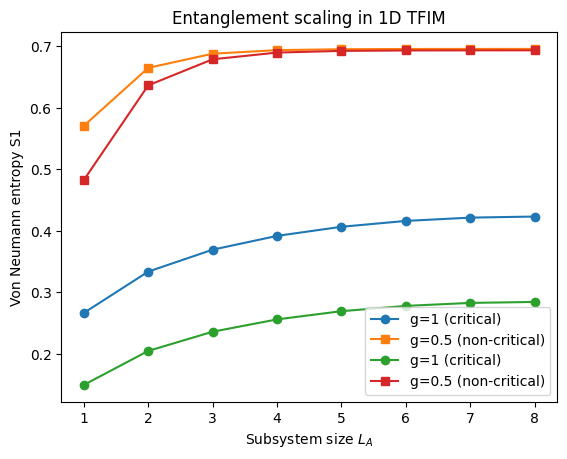

In [11]:
plt.plot(subsys_size, S1_critical, 'o-', label='g=1 (critical)')
plt.plot(subsys_size, S1, 's-', label='g=0.5 (non-critical)')

plt.plot(subsys_size, S2_critical, 'o-', label='g=1 (critical)')
plt.plot(subsys_size, S2, 's-', label='g=0.5 (non-critical)')

plt.xlabel("Subsystem size $L_A$")
plt.ylabel("Von Neumann entropy S1")

plt.title("Entanglement scaling in 1D TFIM")
plt.legend()
plt.show()

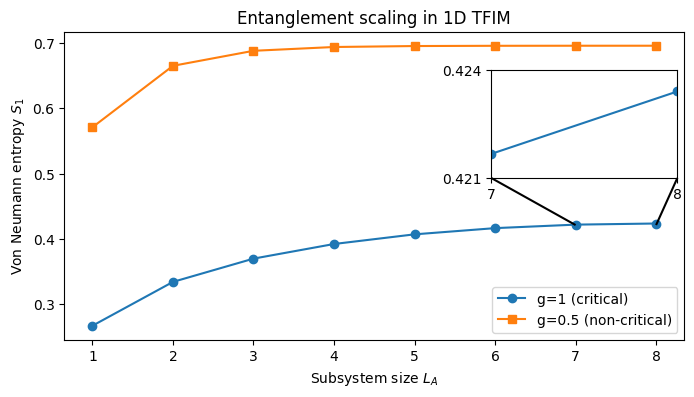

In [12]:
fig, ax = plt.subplots(figsize=(8,4))

# main plot
ax.plot(subsys_size, S1_critical, 'o-', label='g=1 (critical)')
ax.plot(subsys_size, S1, 's-', label='g=0.5 (non-critical)')
ax.set_xlabel("Subsystem size $L_A$")
ax.set_ylabel("Von Neumann entropy $S_1$")
ax.legend()
ax.set_title("Entanglement scaling in 1D TFIM")

# inset for zoom
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

axins = inset_axes(
    ax,
    width="30%", 
    height="35%", 
    loc='center right',             # anchor roughly at center right
    bbox_to_anchor=(0, 0.2, 1, 1),   # (x0, y0) in axes fraction coordinates
    bbox_transform=ax.transAxes     # interpret bbox in axes coordinates
)

axins.plot(subsys_size, S1_critical, 'o-', color='tab:blue')
axins.set_xlim(7, 8)   # zoomed region for small LA
axins.set_ylim(0.421, 0.424)
axins.set_xticks([7,8])
axins.set_yticks([0.421,0.424])
pp, p1, p2 = mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="black", lw=1.5)
pp.set_visible(False)
plt.show()

In [13]:
max(S1_critical[:6]), max(S1_critical[:7])

(np.float64(0.4163045654568832), np.float64(0.42167223504713647))

In [14]:
#testing

L = 16
key = random.PRNGKey(0)

# Choose architecture
arch = FFN(L,[64,64])
# arch = RBM(L,32)
# arch = CNN(L,16,3)

params = arch.init_params(key)

model = NeuralQuantumState(arch,params,L)

sampler = Sampler(model)

H = TFIM(model,J=1.0,g=1.0)

optimizer = Optimizer(model,H,sampler,lr=1e-3)

sigma0 = jnp.ones(L)

params,energy_history = optimizer.optimize(
    key,
    model.params,
    sigma0,
    n_steps=200,
    n_samples=500
)

obs = Observables(model)

samples = sampler.sample_chain(key,params,sigma0,2000)

S2 = obs.renyi2(params,samples,L//4)

print("Renyi-2 entropy:",S2)

TypeError: Optimizer.optimize() got multiple values for argument 'n_steps'